In [117]:
import pandas as pd
import numpy as np
import sklearn as sns
import matplotlib.pyplot as plt

In [118]:
dataset = pd.read_csv(
    "/content/Liver Patient Dataset (LPD)_train.csv",
    encoding="latin1"
)


In [119]:
df = pd.DataFrame(dataset)

In [120]:
df.head()

,Age of the patient,Gender of the patient,Total Bilirubin,Direct Bilirubin,Alkphos Alkaline Phosphotase,Sgpt Alamine Aminotransferase,Sgot Aspartate Aminotransferase,Total Protiens,ALB Albumin,A/G Ratio Albumin and Globulin Ratio,Result
0,65.0,Female,0.7,0.1,187.0,16.0,18.0,6.8,3.3,0.90,1
1,62.0,Male,10.9,5.5,699.0,64.0,100.0,7.5,3.2,0.74,1
2,62.0,Male,7.3,4.1,490.0,60.0,68.0,7.0,3.3,0.89,1
3,58.0,Male,1.0,0.4,182.0,14.0,20.0,6.8,3.4,1.00,1
4,72.0,Male,3.9,2.0,195.0,27.0,59.0,7.3,2.4,0.40,1


DATA PRE-PROCESSING

In [121]:
# RENAMING COLUMNS
df.columns = [
    "Age",
    "Gender",
    "Total_Bilirubin",
    "Direct_Bilirubin",
    "Alkaline_Phosphatase",
    "ALT",
    "AST",
    "Total_Proteins",
    "Albumin",
    "A_G_Ratio",
    "Target"
]



In [122]:
df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphatase,ALT,AST,Total_Proteins,Albumin,A_G_Ratio,Target
0,65.0,Female,0.7,0.1,187.0,16.0,18.0,6.8,3.3,0.90,1
1,62.0,Male,10.9,5.5,699.0,64.0,100.0,7.5,3.2,0.74,1
2,62.0,Male,7.3,4.1,490.0,60.0,68.0,7.0,3.3,0.89,1
3,58.0,Male,1.0,0.4,182.0,14.0,20.0,6.8,3.4,1.00,1
4,72.0,Male,3.9,2.0,195.0,27.0,59.0,7.3,2.4,0.40,1


In [123]:
# Encoding Catagorical Variables
df["Gender"] = df["Gender"].map({"Male" : 1 , "Female" : 0})

In [124]:
df["Gender"].value_counts()

,count
Gender,
1.0,21986
0.0,7803


Handling Missing Values

In [125]:
df.isnull().sum()

,0
Age,2
Gender,902
Total_Bilirubin,648
Direct_Bilirubin,561
Alkaline_Phosphatase,796
ALT,538
AST,462
Total_Proteins,463
Albumin,494
A_G_Ratio,559


Since every row has missing values that are large in number so we have to handle it efficiently

In [126]:
columns = [
    "Age",
    "Gender",
    "Total_Bilirubin",
    "Direct_Bilirubin",
    "Alkaline_Phosphatase",
    "ALT",
    "AST",
    "Total_Proteins",
    "Albumin",
    "A_G_Ratio",
]

for col in columns:
  df[col].fillna(df[col].median() , inplace = True)

/tmp/ipython-input-89021635.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median() , inplace = True)


In [127]:
df.isnull().sum()

,0
Age,0
Gender,0
Total_Bilirubin,0
Direct_Bilirubin,0
Alkaline_Phosphatase,0
ALT,0
AST,0
Total_Proteins,0
Albumin,0
A_G_Ratio,0


In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30691 entries, 0 to 30690
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   30691 non-null  float64
 1   Gender                30691 non-null  float64
 2   Total_Bilirubin       30691 non-null  float64
 3   Direct_Bilirubin      30691 non-null  float64
 4   Alkaline_Phosphatase  30691 non-null  float64
 5   ALT                   30691 non-null  float64
 6   AST                   30691 non-null  float64
 7   Total_Proteins        30691 non-null  float64
 8   Albumin               30691 non-null  float64
 9   A_G_Ratio             30691 non-null  float64
 10  Target                30691 non-null  int64  
dtypes: float64(10), int64(1)
memory usage: 2.6 MB


In [129]:
df.describe()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphatase,ALT,AST,Total_Proteins,Albumin,A_G_Ratio,Target
count,30691.000000,30691.000000,30691.000000,30691.000000,30691.000000,30691.000000,30691.000000,30691.000000,30691.000000,30691.000000,30691.000000
mean,44.107263,0.745756,3.320273,1.505594,286.998534,80.673715,110.424229,6.482044,3.129657,0.942676,1.285882
std,15.980524,0.435442,6.198504,2.847999,235.767615,180.658202,278.857463,1.073887,0.785888,0.320260,0.451841
min,4.000000,0.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,32.000000,0.000000,0.800000,0.200000,176.000000,23.000000,26.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,1.000000,0.300000,209.000000,35.000000,42.000000,6.600000,3.100000,0.900000,1.000000
75%,55.000000,1.000000,2.600000,1.300000,293.000000,61.000000,87.000000,7.200000,3.700000,1.100000,2.000000
max,90.000000,1.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


In [130]:
df["AST_ALT_Ratio"] = df["AST"] / (df["ALT"] + 1e-6)


In [131]:
df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphatase,ALT,AST,Total_Proteins,Albumin,A_G_Ratio,Target,AST_ALT_Ratio
0,65.0,0.0,0.7,0.1,187.0,16.0,18.0,6.8,3.3,0.90,1,1.125000
1,62.0,1.0,10.9,5.5,699.0,64.0,100.0,7.5,3.2,0.74,1,1.562500
2,62.0,1.0,7.3,4.1,490.0,60.0,68.0,7.0,3.3,0.89,1,1.133333
3,58.0,1.0,1.0,0.4,182.0,14.0,20.0,6.8,3.4,1.00,1,1.428571
4,72.0,1.0,3.9,2.0,195.0,27.0,59.0,7.3,2.4,0.40,1,2.185185


In [132]:
df.duplicated().sum()

np.int64(11608)

In [133]:
df.drop_duplicates(inplace=True)


In [134]:
df.duplicated().sum()

np.int64(0)

All the duplicate values are removed

In [135]:
df["Gender"] = df["Gender"].astype(int)


In [136]:
df["Target"] = df["Target"].map({1: 1, 2: 0})


In [137]:
df["Target"].value_counts()

,count
Target,
1,13609
0,5474


EDA(Exploratory Data ANalysis)

In [138]:
df["Target"].value_counts(normalize=True)


,proportion
Target,
1,0.713148
0,0.286852


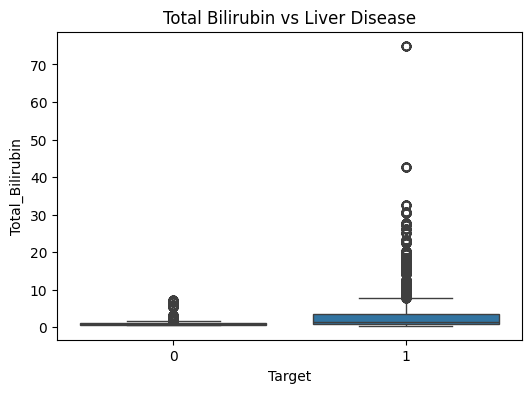

In [139]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(x="Target", y="Total_Bilirubin", data=df)
plt.title("Total Bilirubin vs Liver Disease")
plt.show()


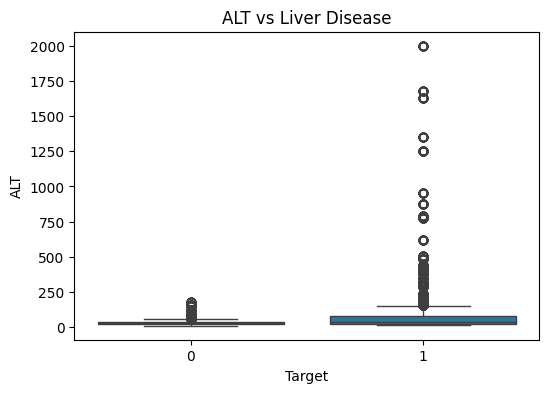

In [140]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(x="Target", y="ALT", data=df)
plt.title("ALT vs Liver Disease")
plt.show()


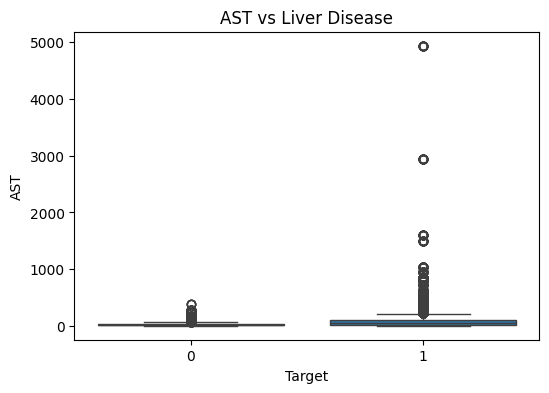

In [141]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(x="Target", y="AST", data=df)
plt.title("AST vs Liver Disease")
plt.show()


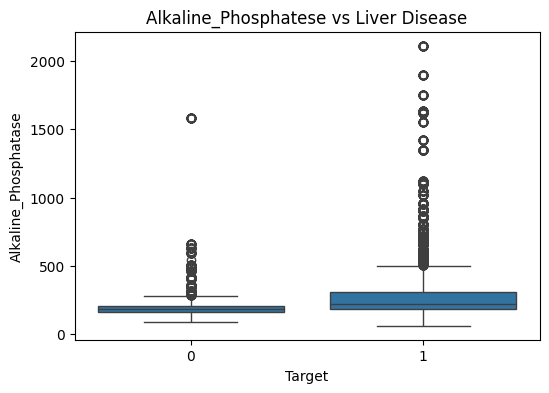

In [142]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(x="Target", y="Alkaline_Phosphatase", data=df)
plt.title("Alkaline_Phosphatese vs Liver Disease")
plt.show()


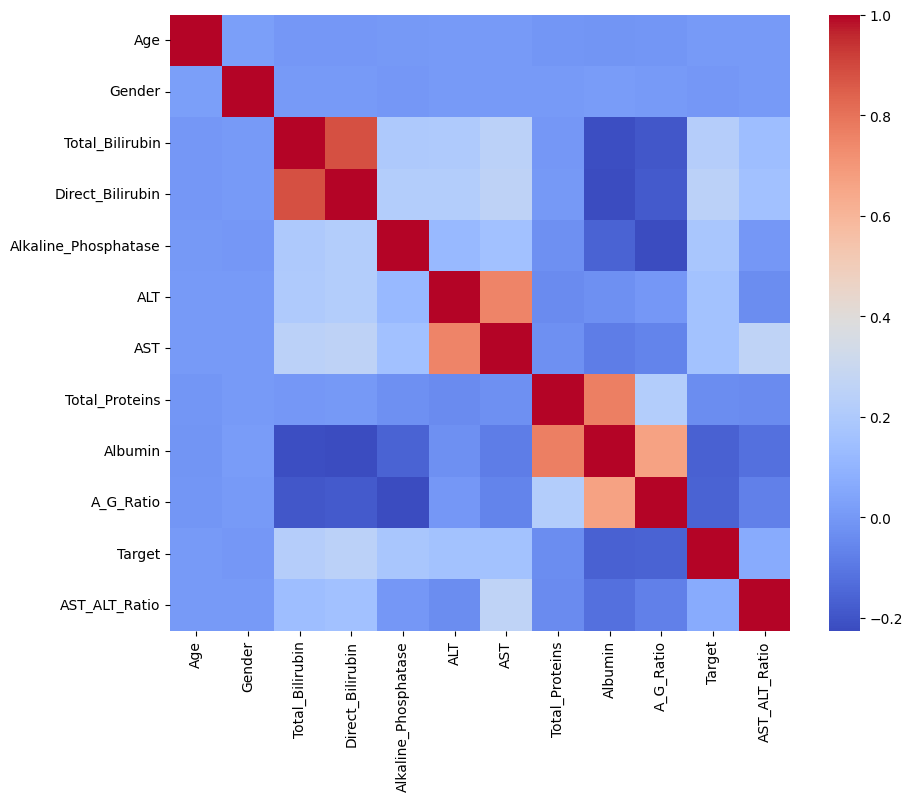

In [143]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.show()


In [144]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix
)

In [145]:
X = df.drop("Target" , axis=1)

In [146]:
y = df["Target"]

In [147]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [148]:
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [149]:
model = LogisticRegression(
    max_iter = 1000,
    class_weight = "balanced",
    random_state = 42
)

model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [150]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]


In [151]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.43      0.87      0.58      1095
           1       0.91      0.54      0.68      2722

    accuracy                           0.64      3817
   macro avg       0.67      0.70      0.63      3817
weighted avg       0.77      0.64      0.65      3817



In [152]:
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)


ROC-AUC: 0.7581106425237956


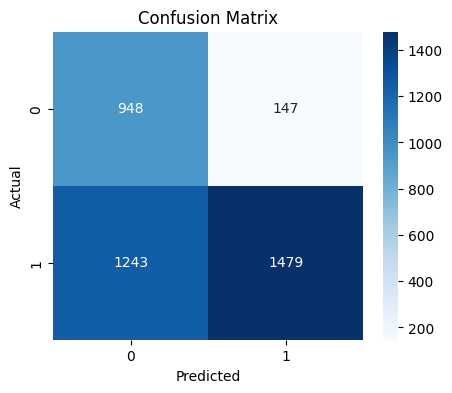

In [153]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [154]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', min_samples_leaf=2,
                       min_samples_split=5, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [155]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]


In [156]:
print(rf_pred , rf_prob)

[1 1 0 ... 1 1 1] [0.99896895 0.99871564 0.01748101 ... 1.         0.99918901 0.99414953]


In [157]:
print("Classification Report : " , classification_report(y_test,rf_pred))

Classification Report :                precision    recall  f1-score   support

           0       0.99      0.99      0.99      1095
           1       1.00      1.00      1.00      2722

    accuracy                           0.99      3817
   macro avg       0.99      0.99      0.99      3817
weighted avg       0.99      0.99      0.99      3817



In [158]:
from sklearn.metrics import roc_auc_score

rf_prob = rf_model.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))


ROC-AUC: 0.9999057233634951


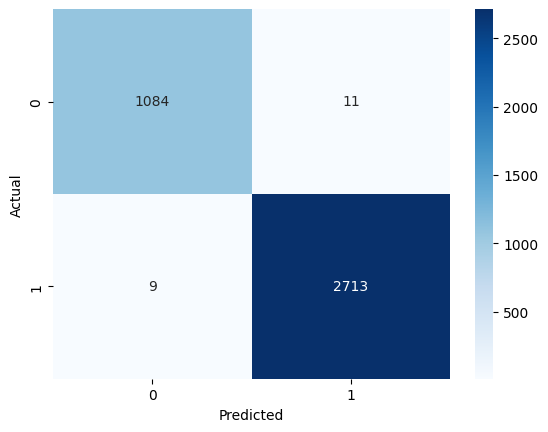

In [159]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


IN both models we can see that the Logistic Regression is not preforming well so choose RandomForest

In [160]:
import joblib

In [161]:
joblib.dump(
    {
        "model": rf_model,
        "features": X_train.columns.tolist()
    },
    "liver_disease_rf_model.pkl"
)


['liver_disease_rf_model.pkl']

In [162]:
loaded = joblib.load("liver_disease_rf_model.pkl")

loaded_model = loaded["model"]
feature_order = loaded["features"]


In [163]:
# take one sample from test set
sample = X_test.iloc[[0]]

# ensure correct column order
sample = sample[feature_order]

prediction = loaded_model.predict(sample)
probability = loaded_model.predict_proba(sample)[:, 1]

print("Prediction:", prediction)
print("Disease Probability:", probability)


Prediction: [1]
Disease Probability: [0.99896895]
